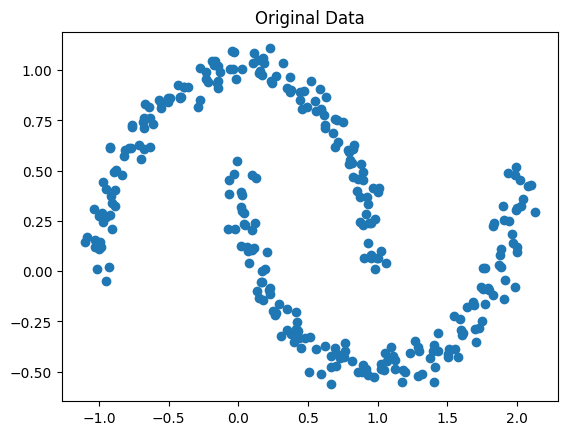

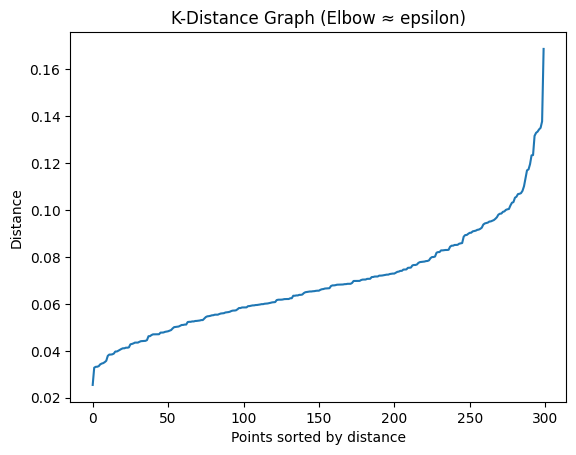

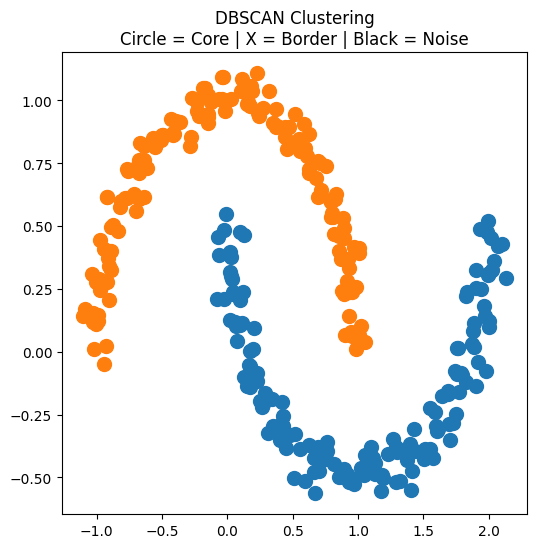

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# 1. Create Sample Dataset
# -----------------------------
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.show()


# -----------------------------
# 2. K-Distance Graph (choose epsilon)
# -----------------------------
k = 4  # MinPts
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:, k-1])

plt.plot(distances)
plt.title("K-Distance Graph (Elbow ≈ epsilon)")
plt.ylabel("Distance")
plt.xlabel("Points sorted by distance")
plt.show()


# -----------------------------
# 3. Apply DBSCAN
# -----------------------------
eps = 0.3
min_samples = 4

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X)

unique_labels = set(labels)

# -----------------------------
# 4. Identify Core / Border / Noise
# -----------------------------
core_samples = db.core_sample_indices_
core_points = np.zeros_like(labels, dtype=bool)
core_points[core_samples] = True


# -----------------------------
# 5. Visualization
# -----------------------------
plt.figure(figsize=(6,6))

for label in unique_labels:

    if label == -1:
        color = "black"   # Noise
    else:
        color = plt.cm.tab10(label)

    class_member_mask = (labels == label)

    # Core points
    xy = X[class_member_mask & core_points]
    plt.scatter(xy[:,0], xy[:,1], c=[color], s=100, marker='o')

    # Border points
    xy = X[class_member_mask & ~core_points]
    plt.scatter(xy[:,0], xy[:,1], c=[color], s=40, marker='x')

plt.title("DBSCAN Clustering\nCircle = Core | X = Border | Black = Noise")
plt.show()